# TP1 · Notebook 02 — Estacionariedad, correlogramas y raíces unitarias
Puntos 2, 3 y 4 de la consigna. Producto final: tabla de decisión con la transformación de varianza y los
órdenes de integración (*d*, *D*) de cada serie, insumo del Notebook 03.

Orden de trabajo: primero se estabiliza la **varianza** (transformación), después la **media** (diferenciación).

## 1. Entorno y carga de las series del Notebook 01

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings, os, glob
from scipy import stats
from statsmodels.tsa.stattools import acovf, acf, pacf, adfuller, kpss, zivot_andrews

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (13, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})

# `arch` aporta Phillips-Perron y DF-GLS (no vienen en statsmodels). Si falla, se sigue con ADF/KPSS/ZA.
try:
    from arch.unitroot import PhillipsPerron, DFGLS
    ARCH_OK = True
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=False)
    try:
        from arch.unitroot import PhillipsPerron, DFGLS
        ARCH_OK = True
    except ImportError:
        ARCH_OK = False
print('arch disponible:', ARCH_OK)

# ---------------- configuración ----------------
NOMBRE_CARPETA = 'DATASETS'
RUTA_DIRECTA   = '/content/drive/MyDrive/TP Analisis de Series Temporales/DATASETS'
S = 12                                    # período estacional (datos mensuales)
COLORES = {'nieve': 'steelblue', 'savi': 'seagreen', 'agua': 'indianred'}
# -----------------------------------------------

try:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
except ImportError:
    pass

CARPETA_DATOS = RUTA_DIRECTA if os.path.isdir(RUTA_DIRECTA) else next(
    (h for raiz in ['/content/drive/MyDrive', '/content', '.'] for n in range(4)
     for h in glob.glob(os.path.join(raiz, *(['*'] * n), NOMBRE_CARPETA)) if os.path.isdir(h)), None)
assert CARPETA_DATOS, f'No se encontró la carpeta {NOMBRE_CARPETA}. Ajustar RUTA_DIRECTA.'
CARPETA_SALIDA = os.path.join(CARPETA_DATOS.rsplit('/', 1)[0], 'OUTPUTS')
os.makedirs(CARPETA_SALIDA, exist_ok=True)

localizar = lambda p: next(iter(sorted(glob.glob(os.path.join(CARPETA_SALIDA, '**', p), recursive=True))), None)
p_completo, p_comun = localizar('01_series_mensuales_completo.csv'), localizar('01_series_mensuales_comun.csv')
assert p_completo and p_comun, 'Faltan los CSV del Notebook 01: ejecutarlo antes que este notebook.'

df_completo = pd.read_csv(p_completo, index_col=0, parse_dates=True).asfreq('MS')
df_comun    = pd.read_csv(p_comun,    index_col=0, parse_dates=True).asfreq('MS')

# nieve usa las 471 observaciones; savi y agua, la ventana común de 105
SERIES = {'nieve': df_completo['nieve'].dropna(),
          'savi' : df_comun['savi'].dropna(),
          'agua' : df_comun['agua'].dropna()}
for k, v in SERIES.items():
    print(f'{k:6s} {v.index.min():%Y-%m} a {v.index.max():%Y-%m}  n = {len(v)}')

arch disponible: True
Mounted at /content/drive
nieve  1986-01 a 2025-03  n = 471
savi   2016-07 a 2025-03  n = 105
agua   2016-07 a 2025-03  n = 105


## 2. Estabilización de la varianza

$\lambda$ de Box-Cox por máxima verosimilitud ($\approx 1$ no transformar · $\approx 0{,}5$ raíz ·
$\approx 0$ logaritmo), contrastado con la correlación media-desvío por bloques anuales y la asimetría.
El diccionario `TRANSFORMACION` se edita a mano tras leer la tabla.

In [2]:
def corr_media_desvio(x, bloque=12):
    nb = len(x) // bloque
    if nb < 3:
        return np.nan
    m = [x.iloc[i*bloque:(i+1)*bloque].mean() for i in range(nb)]
    d = [x.iloc[i*bloque:(i+1)*bloque].std()  for i in range(nb)]
    return np.corrcoef(m, d)[0, 1]

filas = []
for nombre, s in SERIES.items():
    despl = 0.0 if s.min() > 0 else (1.0 if s.min() == 0 else abs(s.min()) + 1.0)  # Box-Cox exige x > 0
    _, lam = stats.boxcox(s.values + despl)
    ls = np.log1p(s)
    filas.append({'serie': nombre, 'lambda BoxCox': lam, 'desplazamiento': despl,
                  'corr m-d nivel': corr_media_desvio(s), 'corr m-d log': corr_media_desvio(ls),
                  'skew nivel': s.skew(), 'skew log': ls.skew()})
display(pd.DataFrame(filas).set_index('serie').round(3))
print('lambda: ~1 -> no transformar | ~0.5 -> raíz cuadrada | ~0 -> logaritmo')

,lambda BoxCox,desplazamiento,corr m-d nivel,corr m-d log,skew nivel,skew log
serie,,,,,,
nieve,-0.064,0.0,0.910,0.051,3.765,0.218
savi,-0.243,0.0,0.849,0.824,0.427,0.352
agua,1.062,0.0,0.166,-0.720,-0.231,-1.411


lambda: ~1 -> no transformar | ~0.5 -> raíz cuadrada | ~0 -> logaritmo


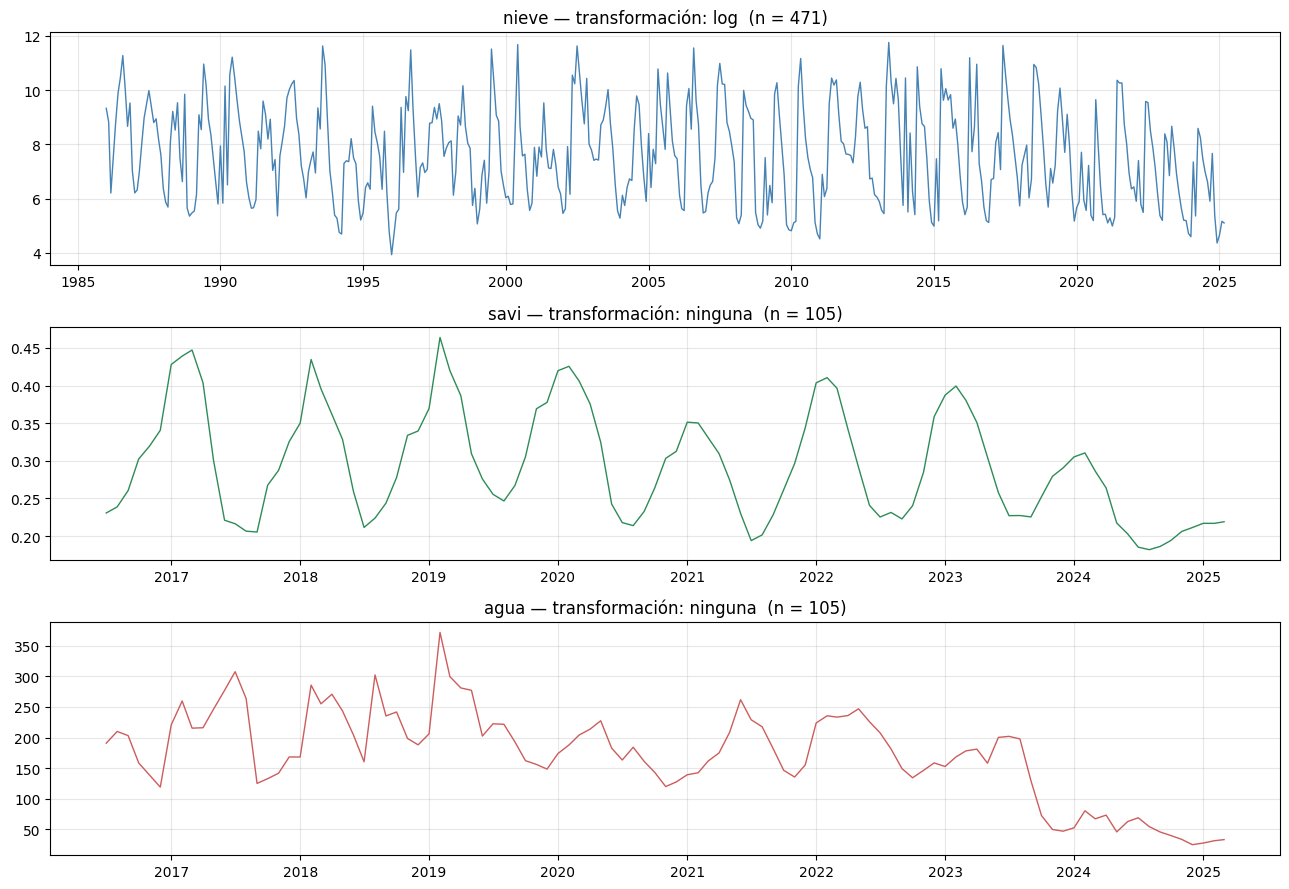

In [3]:
# ---- EDITAR según la tabla anterior: 'ninguna' | 'log' (log1p, admite ceros) | 'sqrt' ----
TRANSFORMACION = {'nieve': 'log',      # lambda ~ 0; la asimetría cae de 3.77 a 0.22
                  'savi' : 'ninguna',  # índice acotado; el log casi no mejora los indicadores
                  'agua' : 'ninguna'}  # lambda ~ 1 y el log empeora la asimetría

transformar = lambda s, t: np.log1p(s) if t == 'log' else (np.sqrt(s) if t == 'sqrt' else s.copy())
SERIES_T = {k: transformar(v, TRANSFORMACION[k]) for k, v in SERIES.items()}

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, (nombre, s) in zip(axes, SERIES_T.items()):
    ax.plot(s.index, s.values, color=COLORES[nombre], lw=1)
    ax.set_title(f'{nombre} — transformación: {TRANSFORMACION[nombre]}  (n = {len(s)})')
plt.tight_layout(); plt.show()

## 3. FAS, FAC y FACP de las series originales *(punto 3)*

FAS = autocovarianza $\gamma_k$ (unidades al cuadrado, no comparable entre series) · FAC = $\rho_k=\gamma_k/\gamma_0$
(asociación total) · FACP = efecto directo del rezago $k$. Bandas $\pm 1{,}96/\sqrt{n}$; líneas naranjas en los
rezagos estacionales.

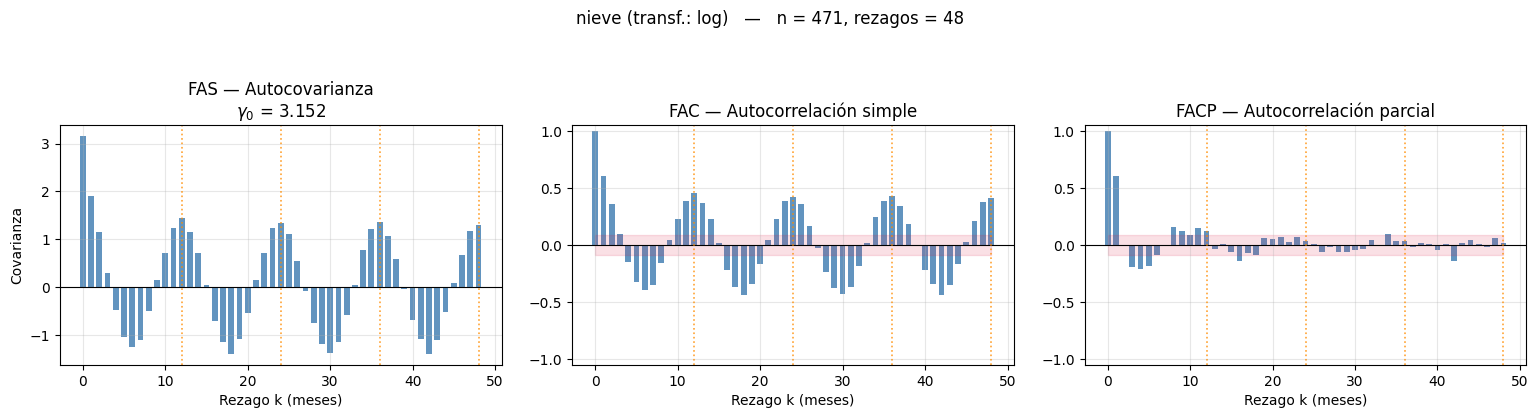

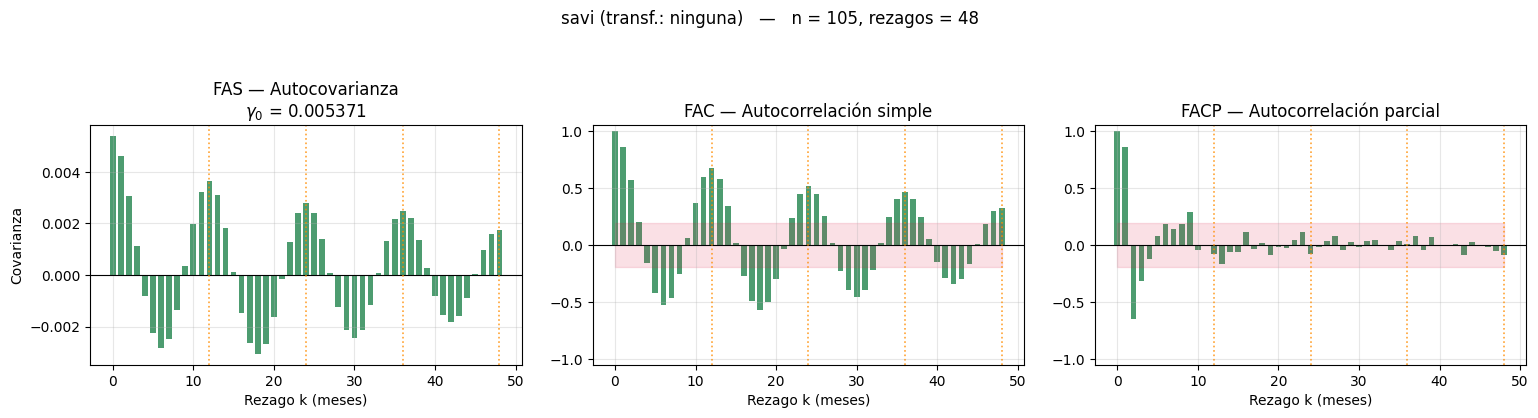

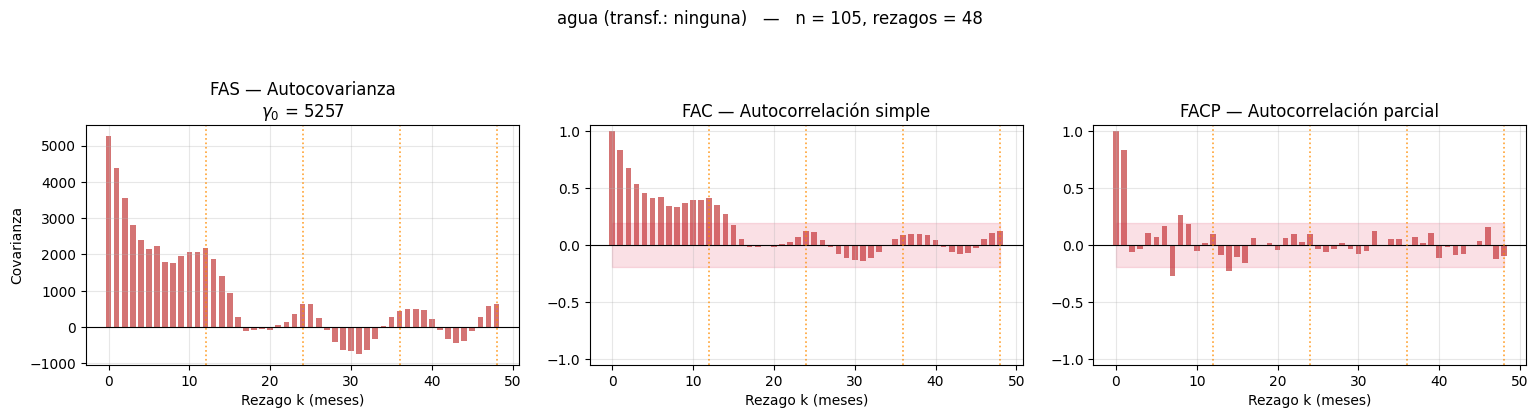

,FAC(1),FAC(6),FAC(12),FAC(24),banda ±,fuera de banda (k=1..24)
serie,,,,,,
nieve,0.607,-0.395,0.460,0.425,0.090,21
savi,0.861,-0.526,0.675,0.521,0.191,20
agua,0.833,0.422,0.416,0.123,0.191,14


In [4]:
def graficar_correlogramas(serie, nombre, lags=None, color='steelblue', sufijo=''):
    '''FAS, FAC y FACP en una sola figura de tres paneles.'''
    s = pd.Series(serie).dropna(); n = len(s)
    lags = max(4, int(min(48, n // 2 - 2)) if lags is None else lags)   # la PACF no existe para lags > n/2

    vals = {'FAS — Autocovarianza': acovf(s.values, nlag=lags, fft=True, demean=True),
            'FAC — Autocorrelación simple': acf(s.values, nlags=lags, fft=True),
            'FACP — Autocorrelación parcial': pacf(s.values, nlags=lags, method='ywm')}
    banda, k = 1.96 / np.sqrt(n), np.arange(lags + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.9))
    for ax, (titulo, v) in zip(axes, vals.items()):
        ax.bar(k, v, color=color, alpha=0.85, width=0.7)
        ax.axhline(0, color='black', lw=0.8)
        ax.set(title=titulo if not titulo.startswith('FAS') else f'{titulo}\n$\\gamma_0$ = {v[0]:.4g}',
               xlabel='Rezago k (meses)')
        if not titulo.startswith('FAS'):
            ax.fill_between(k, -banda, banda, color='crimson', alpha=0.13); ax.set_ylim(-1.05, 1.05)
        for m in range(12, lags + 1, 12):
            ax.axvline(m, color='darkorange', ls=':', lw=1.2, alpha=0.8)
    axes[0].set_ylabel('Covarianza')
    fig.suptitle(f'{nombre}{sufijo}   —   n = {n}, rezagos = {lags}', y=1.06)
    plt.tight_layout(); plt.show()

    return dict(zip(['fas', 'fac', 'facp'], vals.values()), banda=banda)


correlogramas = {n: graficar_correlogramas(s, n, color=COLORES[n],
                                           sufijo=f' (transf.: {TRANSFORMACION[n]})')
                 for n, s in SERIES_T.items()}

display(pd.DataFrame([{'serie': n, 'FAC(1)': d['fac'][1], 'FAC(6)': d['fac'][6],
                       'FAC(12)': d['fac'][12] if len(d['fac']) > 12 else np.nan,
                       'FAC(24)': d['fac'][24] if len(d['fac']) > 24 else np.nan,
                       'banda ±': d['banda'],
                       'fuera de banda (k=1..24)': int(np.sum(np.abs(d['fac'][1:25]) > d['banda']))}
                      for n, d in correlogramas.items()]).set_index('serie').round(3))

## 4. Diferenciación

Criterio de varianza mínima sobre la grilla $(d, D)$. **Advertencia:** para una serie estacionaria
$\mathrm{Var}(\Delta X_t)=2\gamma_0(1-\rho_1)$, de modo que el criterio recomienda diferenciar toda serie con
$\rho_1 > 0{,}5$, tenga o no raíz unitaria. La decisión final cruza este criterio con los correlogramas (sec. 5)
y los tests formales (sec. 6). El ADF, además, no detecta raíces unitarias **estacionales**: $D$ se decide por
varianza y correlograma.

=== nieve ===  mínima varianza en d = 1, D = 0


,,n,varianza,media,"ratio vs (0,0)"
d,D,,,,
0,0,471,3.158974,7.657277,1.000000
1,0,470,2.466292,-0.008986,0.780726
2,0,469,5.887255,0.000937,1.863661
0,1,459,3.302881,-0.068362,1.045555
1,1,458,3.930578,0.006248,1.244258
2,1,457,10.718794,0.002878,3.393125


=== savi ===  mínima varianza en d = 1, D = 1


,,n,varianza,media,"ratio vs (0,0)"
d,D,,,,
0,0,105,0.005423,0.295169,1.000000
1,0,104,0.001427,-0.000112,0.263070
2,0,103,0.001221,-0.000058,0.225142
0,1,93,0.001735,-0.015370,0.319856
1,1,92,0.000645,-0.000577,0.118906
2,1,91,0.001595,0.000485,0.294101


=== agua ===  mínima varianza en d = 1, D = 0


,,n,varianza,media,"ratio vs (0,0)"
d,D,,,,
0,0,105,5307.256201,173.273864,1.000000
1,0,104,1599.306582,-1.514511,0.301343
2,0,103,3351.238932,-0.167721,0.631445
0,1,93,4011.894351,-20.564791,0.755926
1,1,92,2434.510246,-1.637931,0.458714
2,1,91,5401.612323,0.854675,1.017779


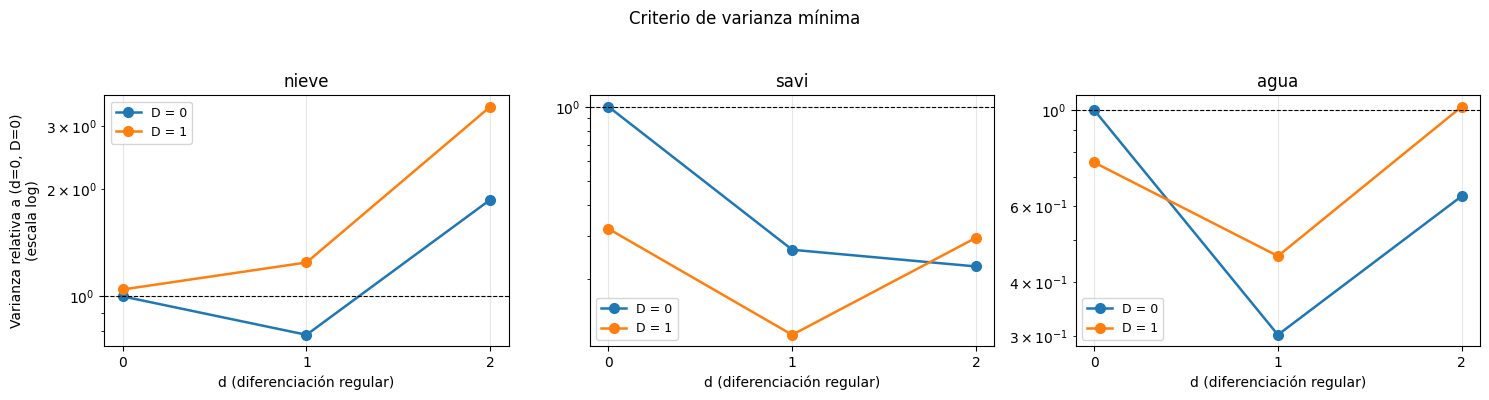

In [5]:
def diferenciar(serie, d=0, D=0, s=S):
    '''D diferencias estacionales (X_t - X_{t-12}) y luego d regulares (X_t - X_{t-1}).'''
    x = pd.Series(serie).copy()
    for _ in range(D):
        x = x.diff(s)
    for _ in range(d):
        x = x.diff()
    return x.dropna()


resultados = {}
for nombre, serie in SERIES_T.items():
    t = pd.DataFrame([{'d': d, 'D': D, 'n': len(x), 'varianza': x.var(), 'media': x.mean()}
                      for D in [0, 1] for d in [0, 1, 2]
                      if len(x := diferenciar(serie, d=d, D=D)) >= 30])
    t['ratio vs (0,0)'] = t['varianza'] / t.loc[(t.d == 0) & (t.D == 0), 'varianza'].values[0]
    resultados[nombre] = t
    opt = t.loc[t['varianza'].idxmin()]
    print(f'=== {nombre} ===  mínima varianza en d = {int(opt.d)}, D = {int(opt.D)}')
    display(t.set_index(['d', 'D']).round(6))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (nombre, t) in zip(axes, resultados.items()):
    for D in sorted(t.D.unique()):
        sub = t[t.D == D]
        ax.plot(sub['d'], sub['ratio vs (0,0)'], 'o-', lw=1.8, ms=7, label=f'D = {D}')
    ax.axhline(1, color='black', lw=0.8, ls='--')
    ax.set(xticks=[0, 1, 2], xlabel='d (diferenciación regular)', title=nombre, yscale='log')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Varianza relativa a (d=0, D=0)\n(escala log)')
plt.suptitle('Criterio de varianza mínima', y=1.04)
plt.tight_layout(); plt.show()

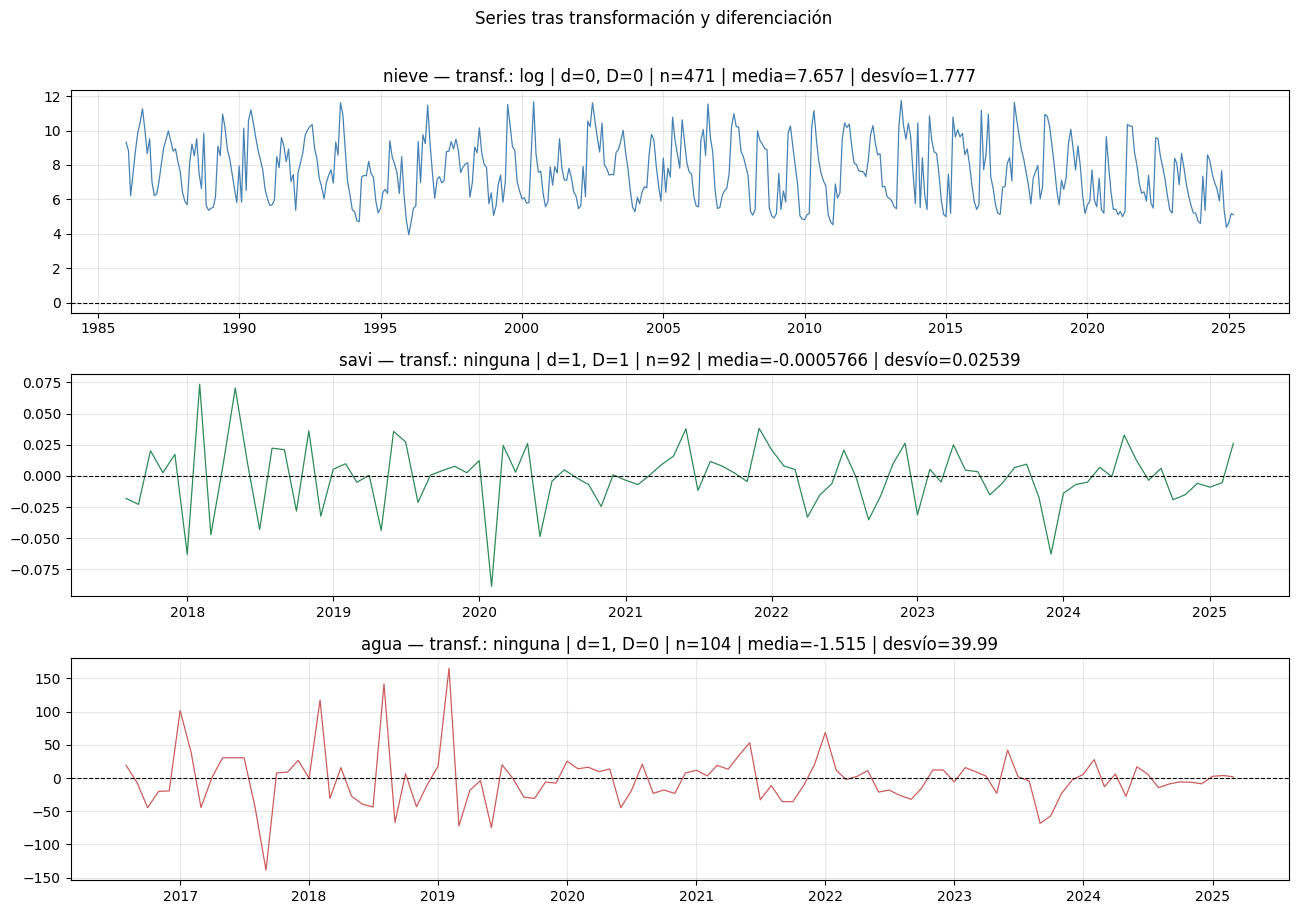

In [6]:
# ---- EDITAR tras contrastar con los correlogramas (sec. 5) y los tests (sec. 6) ----
ORDENES = {'nieve': {'d': 0, 'D': 0},   # FAC(1)=0.607 apenas > 0.5: la caída de varianza es artefacto
           'savi' : {'d': 1, 'D': 1},   # modelo airline: la varianza cae a 0.119
           'agua' : {'d': 1, 'D': 0}}   # d=1 reduce 70 %; D=1 empeora

SERIES_EST = {k: diferenciar(SERIES_T[k], **ORDENES[k]) for k in SERIES_T}

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, (nombre, s) in zip(axes, SERIES_EST.items()):
    o = ORDENES[nombre]
    ax.plot(s.index, s.values, color=COLORES[nombre], lw=0.9)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'{nombre} — transf.: {TRANSFORMACION[nombre]} | d={o["d"]}, D={o["D"]} | '
                 f'n={len(s)} | media={s.mean():.4g} | desvío={s.std():.4g}')
plt.suptitle('Series tras transformación y diferenciación', y=1.01)
plt.tight_layout(); plt.show()

## 5. FAS, FAC y FACP de las series estacionarizadas

Lectura de órdenes: FACP en rezagos bajos → $p$ · FAC en rezagos bajos → $q$ · FACP en 12, 24, 36 → $P$ ·
FAC en 12, 24, 36 → $Q$.

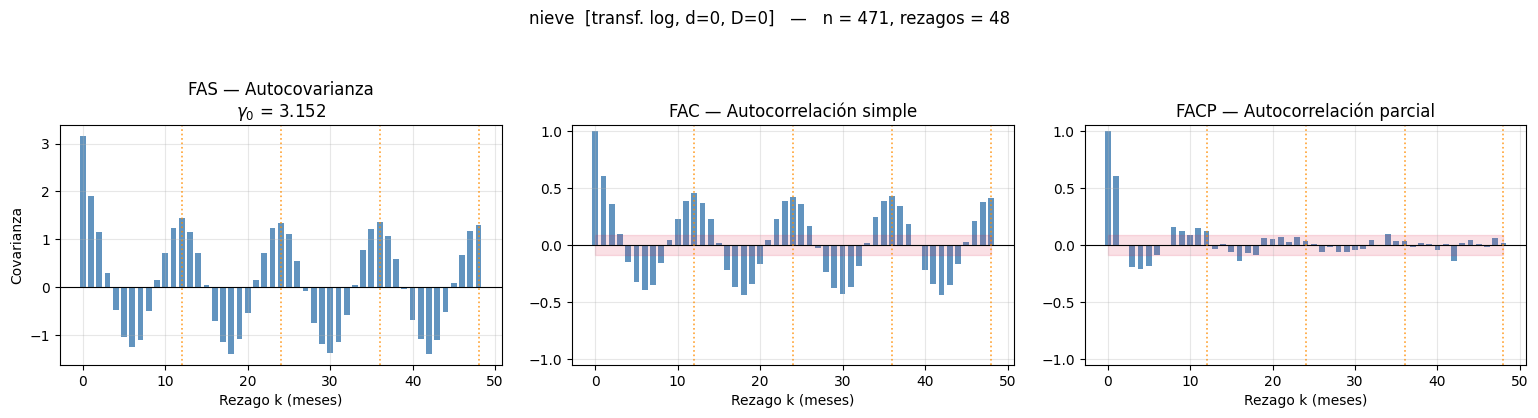

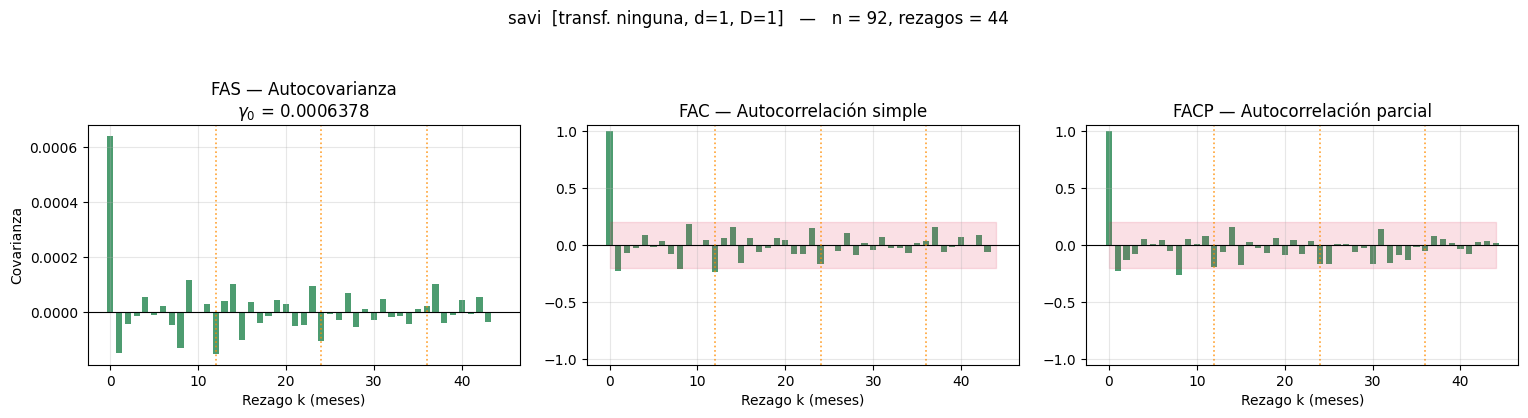

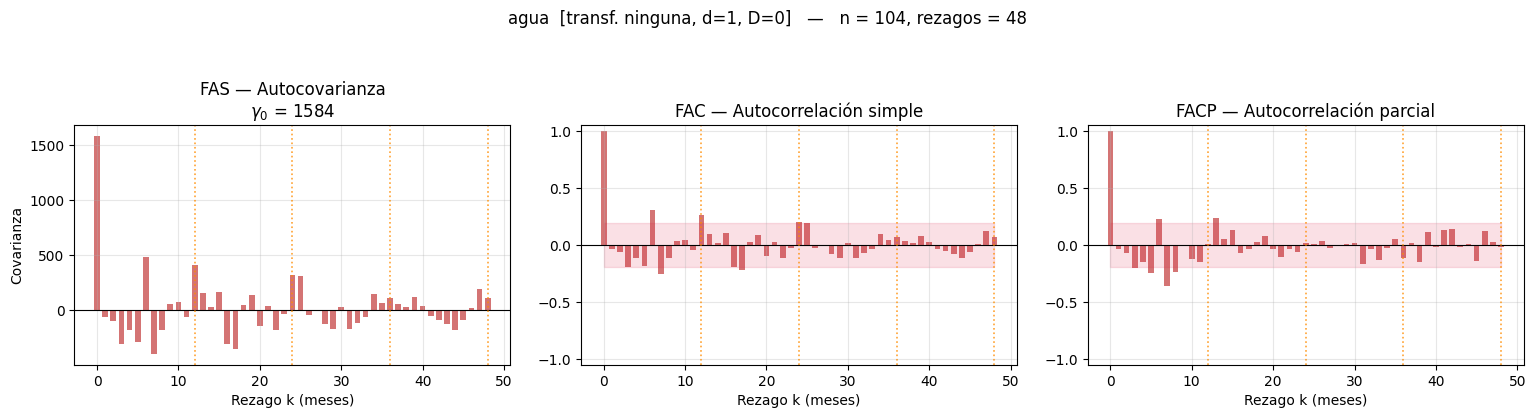

Rezagos que superan la banda de significatividad

--- nieve ---  banda = ±0.090
  FAC : [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 22, 23, 24]
  FACP: [1, 3, 4, 5, 8, 9, 11, 12, 16]
  -> regulares (k<=3): q [1, 2, 3] | p [1, 3]
  -> estacionales (k%12==0): Q [12, 24] | P [12]

--- savi ---  banda = ±0.204
  FAC : [1, 8, 12]
  FACP: [1, 8]
  -> regulares (k<=3): q [1] | p [1]
  -> estacionales (k%12==0): Q [12] | P []

--- agua ---  banda = ±0.192
  FAC : [3, 6, 7, 12, 16, 17, 24]
  FACP: [3, 5, 6, 7, 8, 13]
  -> regulares (k<=3): q [3] | p [3]
  -> estacionales (k%12==0): Q [12, 24] | P []


In [7]:
correlogramas_est = {n: graficar_correlogramas(
        s, n, color=COLORES[n],
        sufijo=f'  [transf. {TRANSFORMACION[n]}, d={ORDENES[n]["d"]}, D={ORDENES[n]["D"]}]')
    for n, s in SERIES_EST.items()}

sig = lambda v, banda, kmax=25: [k for k in range(1, min(kmax, len(v))) if abs(v[k]) > banda]

print('Rezagos que superan la banda de significatividad\n' + '=' * 62)
for nombre, d in correlogramas_est.items():
    f, p = sig(d['fac'], d['banda']), sig(d['facp'], d['banda'])
    print(f'\n--- {nombre} ---  banda = ±{d["banda"]:.3f}')
    print(f'  FAC : {f}\n  FACP: {p}')
    print(f'  -> regulares (k<=3): q {[k for k in f if k <= 3]} | p {[k for k in p if k <= 3]}')
    print(f'  -> estacionales (k%12==0): Q {[k for k in f if k % 12 == 0]} | '
          f'P {[k for k in p if k % 12 == 0]}')

## 6. Pruebas de raíces unitarias *(punto 4)*

| Prueba | $H_0$ | Rechazar $H_0$ significa |
|---|---|---|
| ADF, Phillips-Perron, DF-GLS | hay raíz unitaria | la serie **es** estacionaria |
| KPSS | **es** estacionaria | la serie **no es** estacionaria |
| Zivot-Andrews | raíz unitaria con quiebre | estacionaria alrededor de un quiebre (devuelve la fecha) |

Cada prueba se corre bajo distintas especificaciones determinísticas (`n`, `c`, `ct`).

In [8]:
def bateria_tests(serie):
    '''ADF, KPSS, Phillips-Perron, DF-GLS y Zivot-Andrews bajo distintas especificaciones.'''
    s = pd.Series(serie).dropna(); x = s.values; out = []
    ESPEC = {'n': 'sin constante', 'c': 'constante', 'ct': 'constante+tendencia'}

    for reg in ['n', 'c', 'ct']:                     # ADF: H0 = raíz unitaria
        try:
            est, p, _, _, crit, _ = adfuller(x, regression=reg, autolag='AIC')
            out.append(('ADF', ESPEC[reg], est, p, crit['5%'], 'raíz unitaria', p < 0.05))
        except Exception:
            pass

    for reg in ['c', 'ct']:                          # KPSS: H0 = ES estacionaria (al revés)
        try:
            est, p, _, crit = kpss(x, regression=reg, nlags='auto')
            out.append(('KPSS', ESPEC[reg], est, p, crit['5%'], 'estacionaria', p < 0.05))
        except Exception:
            pass

    if ARCH_OK:
        for Test, nom in [(PhillipsPerron, 'Phillips-Perron'), (DFGLS, 'DF-GLS')]:
            for reg in ['c', 'ct']:
                try:
                    r = Test(x, trend=reg)
                    out.append((nom, ESPEC[reg], r.stat, r.pvalue, r.critical_values['5%'],
                                'raíz unitaria', r.pvalue < 0.05))
                except Exception:
                    pass

    for reg, et in [('c', 'quiebre en nivel'), ('ct', 'quiebre en nivel y tendencia')]:
        try:                                         # statsmodels devuelve el ÍNDICE del quiebre
            est, p, crit, _, idx = zivot_andrews(x, regression=reg)
            fecha = s.index[int(idx)].strftime('%Y-%m') if 0 <= int(idx) < len(s) else '—'
            out.append(('Zivot-Andrews', f'{et} [{fecha}]', est, p, crit['5%'],
                        'raíz unitaria c/quiebre', p < 0.05))
        except Exception:
            pass

    return pd.DataFrame(out, columns=['test', 'especificación', 'estadístico', 'p-valor',
                                      'crit 5%', 'H0', 'rechaza H0'])

In [9]:
tests_nivel, tests_dif = {}, {}
for nombre in SERIES_T:
    o = ORDENES[nombre]
    for etiqueta, serie, destino in [
            (f'transf.: {TRANSFORMACION[nombre]}, SIN diferenciar', SERIES_T[nombre], tests_nivel),
            (f'DIFERENCIADA (d={o["d"]}, D={o["D"]})',              SERIES_EST[nombre], tests_dif)]:
        print('\n' + '=' * 80)
        print(f'{nombre.upper()}  —  {etiqueta}, n = {len(serie)}')
        print('=' * 80)
        destino[nombre] = bateria_tests(serie)
        display(destino[nombre].set_index(['test', 'especificación']).round(4))


def resumir(t):
    r = {}
    for test in ['ADF', 'Phillips-Perron', 'DF-GLS']:
        sub = t[t.test == test]
        if len(sub):
            r[f'{test}: rechaza RU'] = f'{int(sub["rechaza H0"].sum())}/{len(sub)}'
    sub = t[t.test == 'KPSS']
    if len(sub):
        r['KPSS: NO rechaza estac.'] = f'{int((~sub["rechaza H0"].astype(bool)).sum())}/{len(sub)}'
    return r


display(pd.DataFrame([{'serie': n, 'estado': e, **resumir(d[n])}
                      for n in SERIES_T
                      for e, d in [('en nivel', tests_nivel), ('diferenciada', tests_dif)]]
                     ).set_index(['serie', 'estado']))
print('En cada celda: cuántas especificaciones apoyan la ESTACIONARIEDAD sobre el total probado.')


NIEVE  —  transf.: log, SIN diferenciar, n = 471


estadístico  p-valor  \
test            especificación                                                 
ADF             sin constante                               -0.8330   0.3567   
                constante                                   -5.2185   0.0000   
                constante+tendencia                         -5.5669   0.0000   
KPSS            constante                                    0.4982   0.0421   
                constante+tendencia                          0.1174   0.1000   
Phillips-Perron constante                                   -9.5102   0.0000   
                constante+tendencia                         -9.4682   0.0000   
DF-GLS          constante                                   -1.3981   0.1562   
                constante+tendencia                         -3.5792   0.0060   
Zivot-Andrews   quiebre en nivel [2019-05]                  -6.4584   0.0003   
                quiebre en nivel y tendencia [2013-04]      -6.8555   0.0010   

                                                        crit 5%  \
test            especificación                                    
ADF             sin constante                           -1.9416   
                constante                               -2.8679   
                constante+tendencia                     -3.4202   
KPSS            constante                                0.4630   
                constante+tendencia                      0.1460   
Phillips-Perron constante                               -2.8677   
                constante+tendencia                     -3.4199   
DF-GLS          constante                               -1.9903   
                constante+tendencia                     -2.8898   
Zivot-Andrews   quiebre en nivel [2019-05]              -4.8107   
                quiebre en nivel y tendencia [2013-04]  -5.0733   

                                                                             H0  \
test            especificación                                                    
ADF             sin constante                                     raíz unitaria   
                constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
KPSS            constante                                          estacionaria   
                constante+tendencia                                estacionaria   
Phillips-Perron constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
DF-GLS          constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
Zivot-Andrews   quiebre en nivel [2019-05]              raíz unitaria c/quiebre   
                quiebre en nivel y tendencia [2013-04]  raíz unitaria c/quiebre   

                                                        rechaza H0  
test            especificación                                      
ADF             sin constante                                False  
                constante                                     True  
                constante+tendencia                           True  
KPSS            constante                                     True  
                constante+tendencia                          False  
Phillips-Perron constante                                     True  
                constante+tendencia                           True  
DF-GLS          constante                                    False  
                constante+tendencia                           True  
Zivot-Andrews   quiebre en nivel [2019-05]                    True  
                quiebre en nivel y tendencia [2013-04]        True


NIEVE  —  DIFERENCIADA (d=0, D=0), n = 471


estadístico  p-valor  \
test            especificación                                                 
ADF             sin constante                               -0.8330   0.3567   
                constante                                   -5.2185   0.0000   
                constante+tendencia                         -5.5669   0.0000   
KPSS            constante                                    0.4982   0.0421   
                constante+tendencia                          0.1174   0.1000   
Phillips-Perron constante                                   -9.5102   0.0000   
                constante+tendencia                         -9.4682   0.0000   
DF-GLS          constante                                   -1.3981   0.1562   
                constante+tendencia                         -3.5792   0.0060   
Zivot-Andrews   quiebre en nivel [2019-05]                  -6.4584   0.0003   
                quiebre en nivel y tendencia [2013-04]      -6.8555   0.0010   

                                                        crit 5%  \
test            especificación                                    
ADF             sin constante                           -1.9416   
                constante                               -2.8679   
                constante+tendencia                     -3.4202   
KPSS            constante                                0.4630   
                constante+tendencia                      0.1460   
Phillips-Perron constante                               -2.8677   
                constante+tendencia                     -3.4199   
DF-GLS          constante                               -1.9903   
                constante+tendencia                     -2.8898   
Zivot-Andrews   quiebre en nivel [2019-05]              -4.8107   
                quiebre en nivel y tendencia [2013-04]  -5.0733   

                                                                             H0  \
test            especificación                                                    
ADF             sin constante                                     raíz unitaria   
                constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
KPSS            constante                                          estacionaria   
                constante+tendencia                                estacionaria   
Phillips-Perron constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
DF-GLS          constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
Zivot-Andrews   quiebre en nivel [2019-05]              raíz unitaria c/quiebre   
                quiebre en nivel y tendencia [2013-04]  raíz unitaria c/quiebre   

                                                        rechaza H0  
test            especificación                                      
ADF             sin constante                                False  
                constante                                     True  
                constante+tendencia                           True  
KPSS            constante                                     True  
                constante+tendencia                          False  
Phillips-Perron constante                                     True  
                constante+tendencia                           True  
DF-GLS          constante                                    False  
                constante+tendencia                           True  
Zivot-Andrews   quiebre en nivel [2019-05]                    True  
                quiebre en nivel y tendencia [2013-04]        True


SAVI  —  transf.: ninguna, SIN diferenciar, n = 105


...

estadístico  p-valor  \
test            especificación                                                 
ADF             sin constante                               -0.9927   0.2910   
                constante                                    0.1142   0.9670   
                constante+tendencia                         -1.8054   0.7022   
KPSS            constante                                    1.0551   0.0100   
                constante+tendencia                          0.2103   0.0121   
Phillips-Perron constante                                   -2.4391   0.1310   
                constante+tendencia                         -3.5821   0.0314   
DF-GLS          constante                                    0.0519   0.7112   
                constante+tendencia                         -1.2177   0.7374   
Zivot-Andrews   quiebre en nivel [2023-08]                  -3.6915   0.5531   
                quiebre en nivel y tendencia [2021-12]      -4.1022   0.4361   

                                                        crit 5%  \
test            especificación                                    
ADF             sin constante                           -1.9441   
                constante                               -2.8922   
                constante+tendencia                     -3.4573   
KPSS            constante                                0.4630   
                constante+tendencia                      0.1460   
Phillips-Perron constante                               -2.8898   
                constante+tendencia                     -3.4536   
DF-GLS          constante                               -2.1442   
                constante+tendencia                     -3.0436   
Zivot-Andrews   quiebre en nivel [2023-08]              -4.8107   
                quiebre en nivel y tendencia [2021-12]  -5.0733   

                                                                             H0  \
test            especificación                                                    
ADF             sin constante                                     raíz unitaria   
                constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
KPSS            constante                                          estacionaria   
                constante+tendencia                                estacionaria   
Phillips-Perron constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
DF-GLS          constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
Zivot-Andrews   quiebre en nivel [2023-08]              raíz unitaria c/quiebre   
                quiebre en nivel y tendencia [2021-12]  raíz unitaria c/quiebre   

                                                        rechaza H0  
test            especificación                                      
ADF             sin constante                                False  
                constante                                    False  
                constante+tendencia                          False  
KPSS            constante                                     True  
                constante+tendencia                           True  
Phillips-Perron constante                                    False  
                constante+tendencia                           True  
DF-GLS          constante                                    False  
                constante+tendencia                          False  
Zivot-Andrews   quiebre en nivel [2023-08]                   False  
                quiebre en nivel y tendencia [2021-12]       False


AGUA  —  DIFERENCIADA (d=1, D=0), n = 104


estadístico  p-valor  \
test            especificación                                                 
ADF             sin constante                               -2.8877   0.0038   
                constante                                   -3.2479   0.0174   
                constante+tendencia                         -3.4565   0.0443   
KPSS            constante                                    0.0541   0.1000   
                constante+tendencia                          0.0183   0.1000   
Phillips-Perron constante                                  -13.5502   0.0000   
                constante+tendencia                        -14.1715   0.0000   
DF-GLS          constante                                   -0.6926   0.4295   
                constante+tendencia                         -2.0316   0.2861   
Zivot-Andrews   quiebre en nivel [2021-02]                  -4.2446   0.2169   
                quiebre en nivel y tendencia [2021-02]      -4.2863   0.3222   

                                                        crit 5%  \
test            especificación                                    
ADF             sin constante                           -1.9443   
                constante                               -2.8939   
                constante+tendencia                     -3.4599   
KPSS            constante                                0.4630   
                constante+tendencia                      0.1460   
Phillips-Perron constante                               -2.8900   
                constante+tendencia                     -3.4540   
DF-GLS          constante                               -2.1539   
                constante+tendencia                     -3.0540   
Zivot-Andrews   quiebre en nivel [2021-02]              -4.8107   
                quiebre en nivel y tendencia [2021-02]  -5.0733   

                                                                             H0  \
test            especificación                                                    
ADF             sin constante                                     raíz unitaria   
                constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
KPSS            constante                                          estacionaria   
                constante+tendencia                                estacionaria   
Phillips-Perron constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
DF-GLS          constante                                         raíz unitaria   
                constante+tendencia                               raíz unitaria   
Zivot-Andrews   quiebre en nivel [2021-02]              raíz unitaria c/quiebre   
                quiebre en nivel y tendencia [2021-02]  raíz unitaria c/quiebre   

                                                        rechaza H0  
test            especificación                                      
ADF             sin constante                                 True  
                constante                                     True  
                constante+tendencia                           True  
KPSS            constante                                    False  
                constante+tendencia                          False  
Phillips-Perron constante                                     True  
                constante+tendencia                           True  
DF-GLS          constante                                    False  
                constante+tendencia                          False  
Zivot-Andrews   quiebre en nivel [2021-02]                   False  
                quiebre en nivel y tendencia [2021-02]       False

ADF: rechaza RU Phillips-Perron: rechaza RU  \
serie estado                                                     
nieve en nivel                 2/3                         2/2   
      diferenciada             2/3                         2/2   
savi  en nivel                 0/3                         0/2   
      diferenciada             3/3                         2/2   
agua  en nivel                 0/3                         1/2   
      diferenciada             3/3                         2/2   

                   DF-GLS: rechaza RU KPSS: NO rechaza estac.  
serie estado                                                   
nieve en nivel                    1/2                     1/2  
      diferenciada                1/2                     1/2  
savi  en nivel                    0/2                     2/2  
      diferenciada                2/2                     2/2  
agua  en nivel                    0/2                     0/2  
      diferenciada                0/2                     2/2

En cada celda: cuántas especificaciones apoyan la ESTACIONARIEDAD sobre el total probado.


## 7. Diagnóstico de sobrediferenciación

Señales de alarma: la varianza **aumenta** respecto del orden inmediato inferior, o la FAC(1) es fuertemente
negativa (por debajo de $-0{,}4$).

In [10]:
filas = []
for nombre, s in SERIES_EST.items():
    o = ORDENES[nombre]
    fac1 = acf(s.values, nlags=1, fft=True)[1]
    var_menor = (diferenciar(SERIES_T[nombre], d=o['d'] - 1, D=o['D']).var() if o['d'] > 0 else
                 diferenciar(SERIES_T[nombre], d=o['d'], D=o['D'] - 1).var() if o['D'] > 0 else np.nan)
    filas.append({'serie': nombre, 'd': o['d'], 'D': o['D'],
                  'varianza elegida': s.var(), 'varianza orden-1': var_menor, 'FAC(1)': fac1,
                  'alarma': (fac1 < -0.4) or (not np.isnan(var_menor) and s.var() > var_menor)})
display(pd.DataFrame(filas).set_index('serie').round(4))
print('Alarma: FAC(1) < -0.4  o  varianza elegida > varianza del orden inferior.')

,d,D,varianza elegida,varianza orden-1,FAC(1),alarma
serie,,,,,,
nieve,0,0,3.1590,NaN,0.6073,False
savi,1,1,0.0006,0.0017,-0.2320,False
agua,1,0,1599.3066,5307.2562,-0.0389,False


Alarma: FAC(1) < -0.4  o  varianza elegida > varianza del orden inferior.


## 8. Tabla de decisión y exportación para el Notebook 03

In [11]:
decision = pd.DataFrame([
    {'serie': k, 'n': len(SERIES[k]),
     'período': f'{SERIES[k].index.min():%Y-%m} a {SERIES[k].index.max():%Y-%m}',
     'transformación': TRANSFORMACION[k], 'd': ORDENES[k]['d'], 'D': ORDENES[k]['D'], 's': S,
     'n tras diferenciar': len(SERIES_EST[k]),
     'modelo base': f"SARIMA(p,{ORDENES[k]['d']},q)(P,{ORDENES[k]['D']},Q)[{S}]"}
    for k in SERIES]).set_index('serie')
display(decision)

salida = {f'{k}_{etq}': serie
          for k in SERIES
          for etq, serie in [('original', SERIES[k]), ('transformada', SERIES_T[k]),
                             ('estacionaria', SERIES_EST[k])]}

for nombre, obj in [('02_series_estacionarizadas.csv', pd.DataFrame(salida)),
                    ('02_decision_ordenes.csv', decision)]:
    ruta = os.path.join(CARPETA_SALIDA, nombre)
    obj.to_csv(ruta)
    print(f'{nombre}  ({os.path.getsize(ruta)/1024:.1f} KB)  ->  {os.path.abspath(ruta)}')

,n,período,transformación,d,D,s,n tras diferenciar,modelo base
serie,,,,,,,,
nieve,471,1986-01 a 2025-03,log,0,0,12,471,"SARIMA(p,0,q)(P,0,Q)[12]"
savi,105,2016-07 a 2025-03,ninguna,1,1,12,92,"SARIMA(p,1,q)(P,1,Q)[12]"
agua,105,2016-07 a 2025-03,ninguna,1,0,12,104,"SARIMA(p,1,q)(P,0,Q)[12]"


02_series_estacionarizadas.csv  (43.9 KB)  ->  /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/02_series_estacionarizadas.csv
02_decision_ordenes.csv  (0.3 KB)  ->  /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/02_decision_ordenes.csv
